In [3]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving creditcard.csv.zip to creditcard.csv.zip
User uploaded file "creditcard.csv.zip" with length 69155672 bytes


In [4]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
#Unzip the file
with zipfile.ZipFile('creditcard.csv.zip', 'r') as zip_ref:
  zip_ref.extractall()
#Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, average_precision_score, f1_score


In [6]:
#Load data With Pandas
df = pd.read_csv("creditcard.csv")
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


### Upload `creditcard.csv`

Run the cell below to upload your `creditcard.csv` file. A 'Choose Files' button will appear, allowing you to select the file from your local machine.

Once the file is uploaded, you can read it directly using `pd.read_csv('creditcard.csv')`.

I will modify the existing cell to read the file correctly.

In [7]:
#Missing values
df.isnull().sum().sum()

np.int64(0)

In [8]:
#Basic Stats
print(f"\nTime range: {df['Time'].min()} to {df['Time'].max()}")
print(f"Amount range: {df['Amount'].min():.2f} to {df['Amount'].max():.2f}")


Time range: 0.0 to 172792.0
Amount range: 0.00 to 25691.16


In [9]:
#Feature Engineering
#1. Amount Feature Engineering
df['Amount_log'] = np.log1p(df['Amount'])
df['Amount_scaled'] = RobustScaler().fit_transform(df['Amount'].values.reshape(-1,1))

#2. Time Feature Engineering (convert seconds to hours)
df['Time_hour'] = df['Time'] / 3600
df['Time_scaled'] = RobustScaler().fit_transform(df['Time'].values.reshape(-1,1))

#Drop original features
df_proceed = df.drop(['Time', 'Amount',], axis=1)

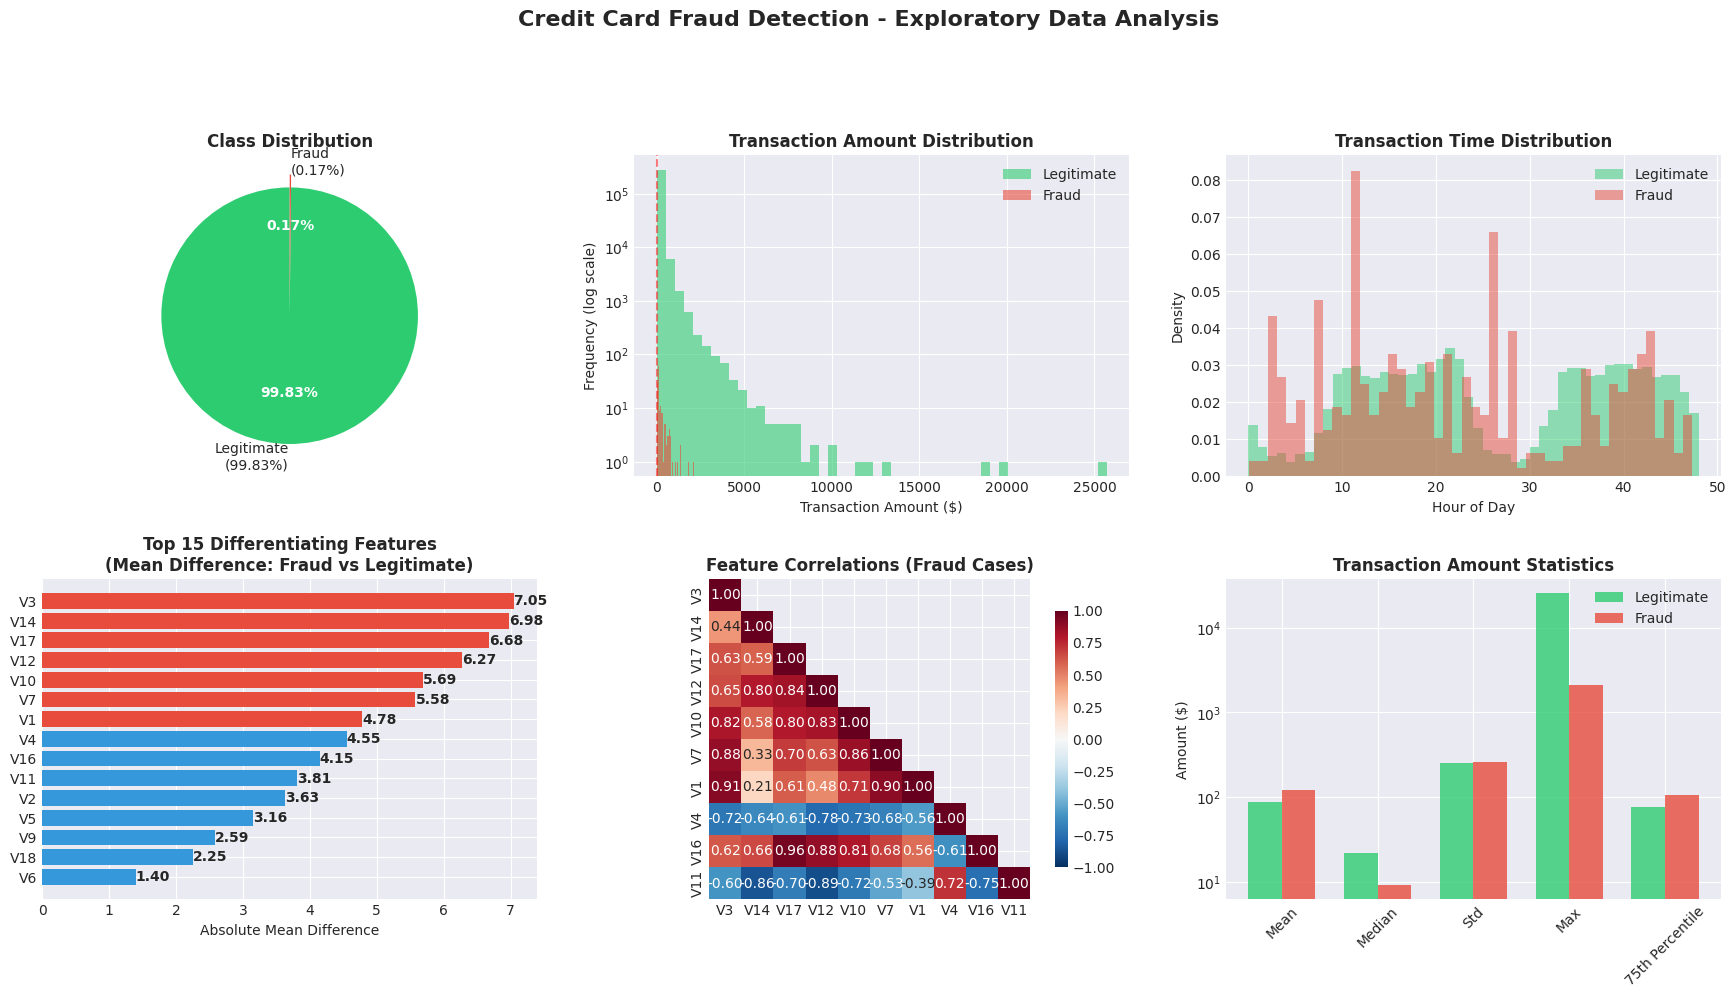


KEY INSIGHTS FROM EDA

1. CLASS IMBALANCE:
   - Fraudulent transactions: 492 (0.173%)
   - Legitimate transactions: 284,315 (99.827%)

2. TRANSACTION AMOUNTS:
   - Mean legitimate amount: $88.29
   - Mean fraud amount: $122.21
   - Median fraud amount: $9.25

3. MOST DISCRIMINATIVE FEATURES:
   - V3: Mean diff = 7.045
   - V14: Mean diff = 6.984
   - V17: Mean diff = 6.677
   - V12: Mean diff = 6.270
   - V10: Mean diff = 5.687

4. TIME PATTERNS:
   - Peak fraud hour: 18.9 (hour of day)
   - Fraud distribution shows temporal patterns worth investigating


In [10]:
#EDA Visualization
# Set style without LaTeX to avoid font warnings
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Credit Card Fraud Detection - Exploratory Data Analysis',
             fontsize=16, fontweight='bold', y=1.02)

# 1. Class Distribution - Pie Chart
colors = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[0,0].pie(
    df['Class'].value_counts(),
    labels=['Legitimate\n(99.83%)', 'Fraud\n(0.17%)'],
    colors=colors,
    autopct='%1.2f%%',
    startangle=90,
    explode=(0, 0.1)
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
axes[0,0].set_title('Class Distribution', fontsize=12, fontweight='bold')

# 2. Transaction Amount Distribution
ax2 = axes[0,1]
for class_val, color, label in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraud')]:
    subset = df[df['Class'] == class_val]['Amount']
    ax2.hist(subset, bins=50, alpha=0.6, color=color, label=label, log=True)
ax2.set_xlabel('Transaction Amount ($)')
ax2.set_ylabel('Frequency (log scale)')
ax2.set_title('Transaction Amount Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.axvline(df[df['Class']==1]['Amount'].median(), color='red',
            linestyle='--', alpha=0.5, label='Median Fraud Amount')

# 3. Transaction Time Pattern
ax3 = axes[0,2]
df['Hour'] = df['Time'] / 3600
for class_val, color, label in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraud')]:
    data = df[df['Class'] == class_val]['Hour']
    ax3.hist(data, bins=48, alpha=0.5, density=True,
            color=color, label=label)
ax3.set_xlabel('Hour of Day')
ax3.set_ylabel('Density')
ax3.set_title('Transaction Time Distribution', fontsize=12, fontweight='bold')
ax3.legend()

# 4. Top Differentiating Features
ax4 = axes[1,0]
# Calculate mean difference for each feature
feature_diff = pd.DataFrame({
    'Feature': [f'V{i}' for i in range(1, 29)],
    'Fraud_Mean': [df[df['Class']==1][f'V{i}'].mean() for i in range(1, 29)],
    'Legit_Mean': [df[df['Class']==0][f'V{i}'].mean() for i in range(1, 29)]
})
feature_diff['Abs_Diff'] = abs(feature_diff['Fraud_Mean'] - feature_diff['Legit_Mean'])
top_features = feature_diff.nlargest(15, 'Abs_Diff')

# Create horizontal bar chart
bars = ax4.barh(range(len(top_features)), top_features['Abs_Diff'].values,
                color=['#e74c3c' if x > top_features['Abs_Diff'].median() else '#3498db'
                      for x in top_features['Abs_Diff']])
ax4.set_yticks(range(len(top_features)))
ax4.set_yticklabels(top_features['Feature'].values)
ax4.set_xlabel('Absolute Mean Difference')
ax4.set_title('Top 15 Differentiating Features\n(Mean Difference: Fraud vs Legitimate)',
             fontsize=12, fontweight='bold')
ax4.invert_yaxis()

# Add value labels on bars
for i, (bar, val) in enumerate(zip(bars, top_features['Abs_Diff'].values)):
    ax4.text(val, bar.get_y() + bar.get_height()/2, f'{val:.2f}',
            ha='left', va='center', fontweight='bold')

# 5. Feature Correlation Heatmap
ax5 = axes[1,1]
# Correlation matrix of top features
top_feature_cols = top_features['Feature'].tolist()[:10]
correlation_data = df[df['Class']==1][top_feature_cols].corr()
mask = np.triu(np.ones_like(correlation_data), k=1)
sns.heatmap(correlation_data, mask=mask, annot=True, fmt='.2f',
           cmap='RdBu_r', center=0, square=True, ax=ax5,
           cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
ax5.set_title('Feature Correlations (Fraud Cases)', fontsize=12, fontweight='bold')

# 6. Transaction Amount Analysis by Class
ax6 = axes[1,2]
stats_data = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Std', 'Max', '75th Percentile'],
    'Legitimate': [
        df[df['Class']==0]['Amount'].mean(),
        df[df['Class']==0]['Amount'].median(),
        df[df['Class']==0]['Amount'].std(),
        df[df['Class']==0]['Amount'].max(),
        df[df['Class']==0]['Amount'].quantile(0.75)
    ],
    'Fraud': [
        df[df['Class']==1]['Amount'].mean(),
        df[df['Class']==1]['Amount'].median(),
        df[df['Class']==1]['Amount'].std(),
        df[df['Class']==1]['Amount'].max(),
        df[df['Class']==1]['Amount'].quantile(0.75)
    ]
})

x = np.arange(len(stats_data['Statistic']))
width = 0.35
ax6.bar(x - width/2, stats_data['Legitimate'], width,
       label='Legitimate', color='#2ecc71', alpha=0.8)
ax6.bar(x + width/2, stats_data['Fraud'], width,
       label='Fraud', color='#e74c3c', alpha=0.8)
ax6.set_xticks(x)
ax6.set_xticklabels(stats_data['Statistic'], rotation=45)
ax6.set_ylabel('Amount ($)')
ax6.set_title('Transaction Amount Statistics', fontsize=12, fontweight='bold')
ax6.legend()
ax6.set_yscale('log')

plt.tight_layout(pad=3.0)
plt.show()

# Print key findings
print("\n" + "="*60)
print("KEY INSIGHTS FROM EDA")
print("="*60)
print(f"\n1. CLASS IMBALANCE:")
print(f"   - Fraudulent transactions: {df['Class'].sum():,} ({df['Class'].mean()*100:.3f}%)")
print(f"   - Legitimate transactions: {(df['Class']==0).sum():,} ({(1-df['Class'].mean())*100:.3f}%)")

print(f"\n2. TRANSACTION AMOUNTS:")
print(f"   - Mean legitimate amount: ${df[df['Class']==0]['Amount'].mean():.2f}")
print(f"   - Mean fraud amount: ${df[df['Class']==1]['Amount'].mean():.2f}")
print(f"   - Median fraud amount: ${df[df['Class']==1]['Amount'].median():.2f}")

print(f"\n3. MOST DISCRIMINATIVE FEATURES:")
for i, row in top_features.head(5).iterrows():
    print(f"   - {row['Feature']}: Mean diff = {row['Abs_Diff']:.3f}")

print(f"\n4. TIME PATTERNS:")
peak_fraud_hour = df[df['Class']==1]['Hour'].mode()[0]
print(f"   - Peak fraud hour: {peak_fraud_hour:.1f} (hour of day)")
print(f"   - Fraud distribution shows temporal patterns worth investigating")

In [11]:
from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek, SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipeline

X = df_proceed.drop('Class', axis=1)
y = df_proceed['Class']

# Split BEFORE resampling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Try different sampling strategies
samplers = {
    'SMOTE': SMOTE(random_state=42, sampling_strategy=0.1),  # 10% fraud ratio
    'ADASYN': ADASYN(random_state=42, sampling_strategy=0.1),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42, sampling_strategy=0.1),
    'SMOTE_Tomek': SMOTETomek(random_state=42, sampling_strategy=0.1),
    'SMOTE_ENN': SMOTEENN(random_state=42, sampling_strategy=0.1),
    'UnderSampling': RandomUnderSampler(random_state=42, sampling_strategy=0.1)
}

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              IsolationForest)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import OneClassSVM

# Define models with focus on recall for fraud class
models = {
    'LogisticRegression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42
    ),
    'RandomForest': RandomForestClassifier(
        n_estimators=100, class_weight='balanced_subsample',
        max_depth=10, min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        max_depth=6, learning_rate=0.1, n_estimators=100,
        subsample=0.8, colsample_bytree=0.8, random_state=42
    ),
    'LightGBM': LGBMClassifier(
        class_weight='balanced', max_depth=-1, learning_rate=0.05,
        n_estimators=100, num_leaves=31, random_state=42, verbose=-1
    ),
    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42
    )
}

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Comprehensive model evaluation"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    results = {
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_pred_proba),
        'PR-AUC': average_precision_score(y_test, y_pred_proba)
    }

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    return results, cm, y_pred_proba

In [13]:
#Training with Cross-Validation
from sklearn.model_selection import StratifiedKFold

def cross_validate_model(model, X, y, cv=5):
    """Stratified K-Fold Cross Validation"""
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)

    scores = {
        'accuracy': [], 'precision': [], 'recall': [], 'f1': [], 'roc_auc': [], 'pr_auc': []
    }
    for train_idx, val_idx in skf.split(X, y):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        #Apply SMOTE only to training folds
        smote = SMOTE(random_state=42)
        X_train_res, y_train_res = smote.fit_resample(X_train_fold, y_train_fold)
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_val_fold)
        y_pred_proba = model.predict_proba(X_val_fold)[:, 1]

        scores['accuracy'].append(accuracy_score(y_val_fold, y_pred))
        scores['precision'].append(precision_score(y_val_fold, y_pred))
        scores['recall'].append(recall_score(y_val_fold, y_pred))
        scores['f1'].append(f1_score(y_val_fold, y_pred))
        scores['roc_auc'].append(roc_auc_score(y_val_fold, y_pred_proba))
        scores['pr_auc'].append(average_precision_score(y_val_fold, y_pred_proba))

    return {
        metric: (np.mean(values), np.std(values))
        for metric, values in scores.items()
    }


In [14]:
#Advanced techniques -- Ensemble Learning
from sklearn.ensemble import VotingClassifier, StackingClassifier

# Voting Ensemble
voting_clf = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(class_weight='balanced', random_state=42)),
        ('xgb', XGBClassifier(scale_pos_weight=577, random_state=42)),
        ('lgbm', LGBMClassifier(class_weight='balanced', random_state=42))
    ],
    voting='soft',
    weights=[1, 2, 2]  # Give more weight to better performers
)

# Stacking Ensemble
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42)),
    ('lgbm', LGBMClassifier(n_estimators=100, random_state=42))
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

In [15]:
#Advanced techniques -- Anomaly Detection
# Autoencoder for feature learning & Deep Learning(Neural Network)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

def build_autoencoder(input_dim, encoding_dim=15):
    """Build autoencoder for anomaly detection"""
    input_layer = Input(shape=(input_dim,))

    # Encoder
    encoded = Dense(encoding_dim*2, activation='relu')(input_layer)
    encoded = Dropout(0.2)(encoded)
    encoded = Dense(encoding_dim, activation='relu')(encoded)

    # Decoder
    decoded = Dense(encoding_dim*2, activation='relu')(encoded)
    decoded = Dropout(0.2)(decoded)
    decoded = Dense(input_dim, activation='sigmoid')(decoded)

    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder

# Train autoencoder on legitimate transactions only
X_normal = X_train[y_train == 0]

scaler = RobustScaler()
X_normal_scaled = scaler.fit_transform(X_normal)

autoencoder = build_autoencoder(X_normal.shape[1])
autoencoder.fit(
    X_normal_scaled, X_normal_scaled,
    epochs=50,
    batch_size=256,
    validation_split=0.1,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)

# Use reconstruction error as anomaly score
X_test_scaled = scaler.transform(X_test)
reconstructions = autoencoder.predict(X_test_scaled)
mse = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [25]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from scipy.stats import uniform, randint

# LGBM: Fewer iterations and fold
# This random_search was fitted, but then overwritten.
# random_search = RandomizedSearchCV(
#     lgbm, lgbm_params, n_iter=20, cv=3, scoring='recall',
#     n_jobs=-1, verbose=2, random_state=42
# )
# #Fit Random Search
# random_search.fit(X_train, y_train)

#Sample the training data & train
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=10000, stratify=y_train, random_state=42
)

#Add early stopping to the model
lgbm = LGBMClassifier(random_state=42, verbose=-1, early_stopping_rounds=50, eval_metrics='recall', device='gpu')

#Pipeline & SMOTE
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline applies SMOTE only on training folds
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42, verbose=-1))
])

random_search = RandomizedSearchCV(
    pipeline,
    {'lgbm__' + k: v for k, v in lgbm_params.items()},
    n_iter=10, cv=2, scoring='recall',
    n_jobs=-1, verbose=2
)

# Fit the new random_search instance
random_search.fit(X_train, y_train)

Fitting 2 folds for each of 10 candidates, totalling 20 fits


RandomizedSearchCV(cv=2,
                   estimator=Pipeline(steps=[('smote', SMOTE(random_state=42)),
                                             ('lgbm',
                                              LGBMClassifier(random_state=42,
                                                             verbose=-1))]),
                   n_jobs=-1,
                   param_distributions={'lgbm__colsample_bytree': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c15d41a5310>,
                                        'lgbm__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen o...
                                        'lgbm__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c15e53aa120>,
                                        'lgbm__num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7c165e7f20c0>,
                                        'lgbm__scale_pos_weight': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c15d41a7a70>,
                                        'lgbm__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7c15d41a4ce0>},
                   scoring='recall', verbose=2)

In [24]:
print(f"Training shape: {X_train.shape}")  # If >100k rows, consider sampling

Training shape: (227845, 32)


In [26]:
print("Best parameters:", random_search.best_params_)
print("Best recall score:", random_search.best_score_)
print("Best model:", random_search.best_estimator_)

Best parameters: {'lgbm__colsample_bytree': np.float64(0.8546048056422733), 'lgbm__learning_rate': np.float64(0.3022247534426415), 'lgbm__max_depth': 6, 'lgbm__min_child_samples': 21, 'lgbm__n_estimators': 499, 'lgbm__num_leaves': 25, 'lgbm__scale_pos_weight': np.float64(743.531606890648), 'lgbm__subsample': np.float64(0.99279501930277)}
Best recall score: 0.984771573604061
Best model: Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('lgbm',
                 LGBMClassifier(colsample_bytree=np.float64(0.8546048056422733),
                                learning_rate=np.float64(0.3022247534426415),
                                max_depth=6, min_child_samples=21,
                                n_estimators=499, num_leaves=25,
                                random_state=42,
                                scale_pos_weight=np.float64(743.531606890648),
                                subsample=np.float64(0.99279501930277),
                                verbose=-1))

In [39]:
#Threshold Optimization
from sklearn.metrics import precision_recall_curve
def find_optimal_threshold(y_true, y_pred_proba, target_recall=0.95):
    """Find threshold that meets target recall while maximizing precision"""
    precisions, recall, thresholds = precision_recall_curve(y_true, y_pred_proba)
    #Find threshold closest to target recall
    idx = np.argmin(np.abs(recall - target_recall))
    optimal_threshold = thresholds[idx]

    #Calculate metrics at this threshold
    y_pred_adjusted = (y_pred_proba >= optimal_threshold).astype(int)

    print(f"Optimal Threshold: {optimal_threshold:.4f}")
    print(f"Recall: {recall[idx]:.4f}")
    print(f"Precision: {precisions[idx]:.4f}")

    return optimal_threshold, recall[idx], precisions[idx]

# Get predictions from the best model found by RandomizedSearchCV
y_pred_proba = random_search.best_estimator_.predict_proba(X_test)[:, 1]

#Apply threshold optimization, assigning values to unique names to avoid conflicts
optimal_threshold_val, optimal_recall_value, optimal_precision_value = find_optimal_threshold(
    y_test, y_pred_proba,
    target_recall=0.95
)

Optimal Threshold: 0.0000
Recall: 0.9796
Precision: 0.0029


In [ ]:
!pip install --upgrade pip

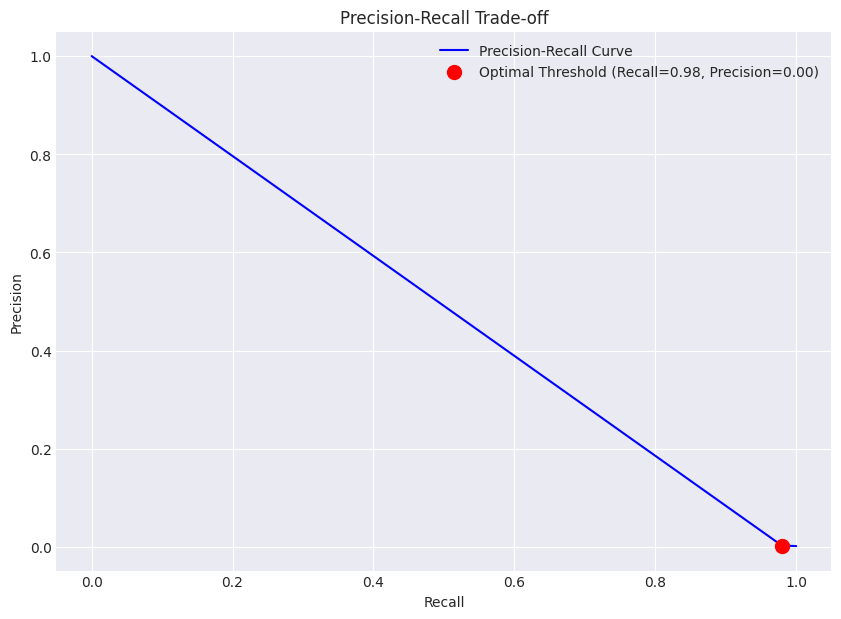

In [40]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Get precision, recall, and thresholds from the curve (these are arrays)
curve_precisions, curve_recalls, curve_thresholds = precision_recall_curve(y_test, y_pred_proba)

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 7))
sns.lineplot(x=curve_recalls, y=curve_precisions, color='blue', label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Trade-off')
plt.grid(True)

# Highlight the optimal threshold point using the values obtained from find_optimal_threshold
# The variables optimal_recall_value and optimal_precision_value are now available from the previous cell.
plt.scatter(optimal_recall_value, optimal_precision_value, color='red', s=100, zorder=5,
            label=f'Optimal Threshold (Recall={optimal_recall_value:.2f}, Precision={optimal_precision_value:.2f})')
plt.legend()
plt.show()

This plot shows the trade-off between precision and recall at different classification thresholds. As expected, increasing recall (moving right along the x-axis) generally leads to a decrease in precision (moving down along the y-axis).

The red dot marks the `optimal_threshold` that was calculated to achieve a target recall of 0.95. At this point, the model achieves a high recall, indicating that it successfully identifies most fraudulent transactions. However, the corresponding precision is very low, meaning a high number of legitimate transactions are also flagged as fraud. This balance is often acceptable in fraud detection, where minimizing false negatives (missed fraud) is prioritized over minimizing false positives (false alarms).

In [41]:
#Install SHAP
!pip install shap

Generating SHAP plots...


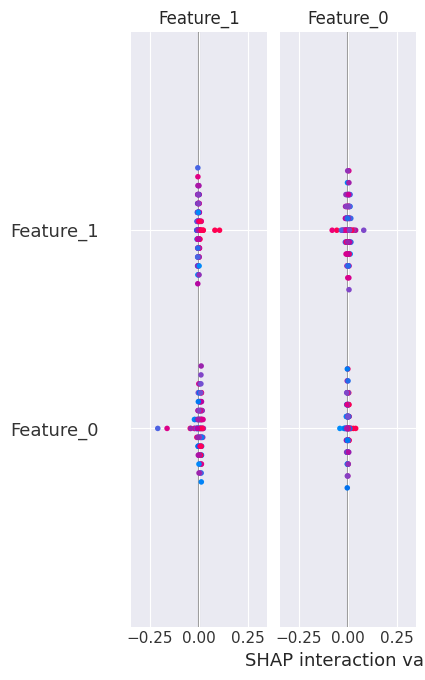

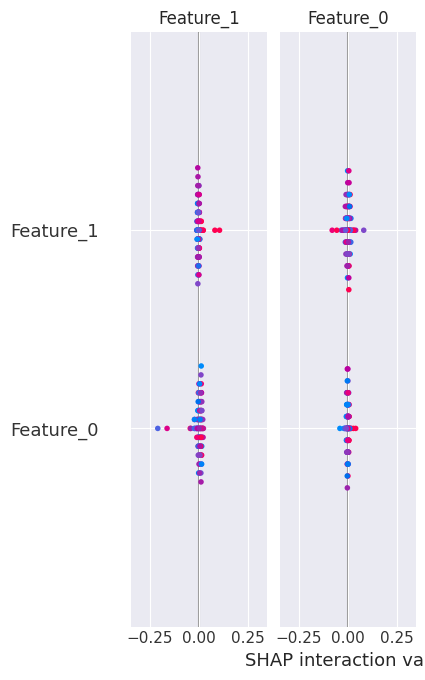


Generating feature importance plot...


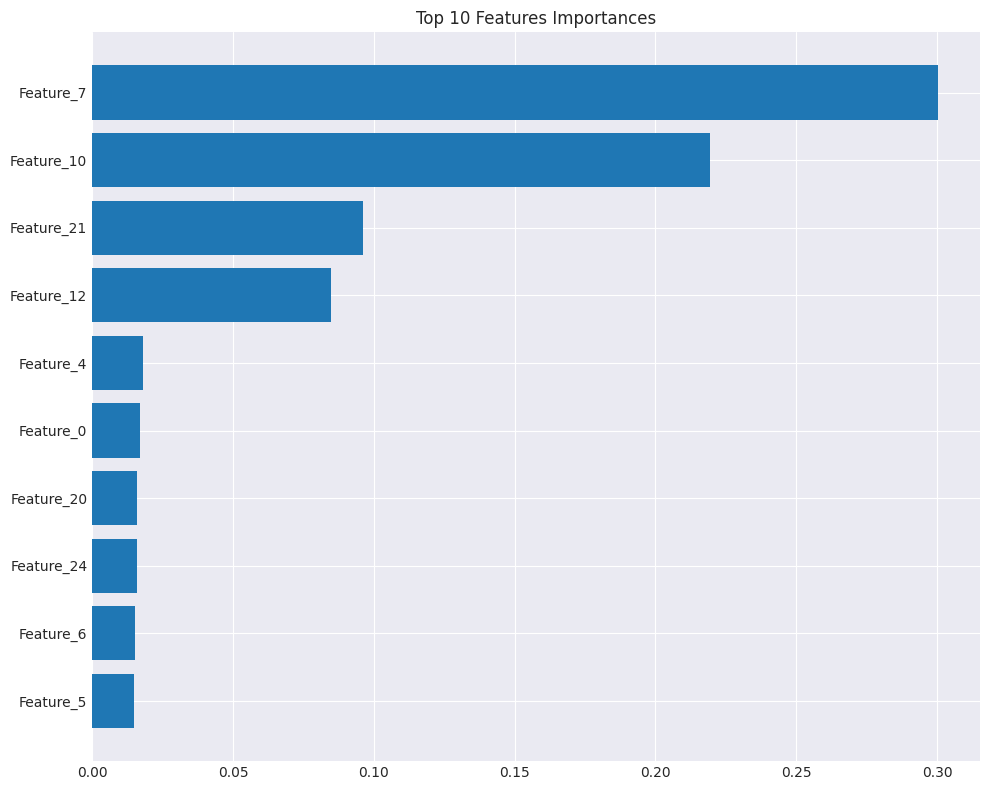

In [48]:
# Model Evaluation & Interpretation
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Create sample data
X, y = make_classification(n_samples=1000, n_features=25, random_state=42)
feature_names = [f'Feature_{i}' for i in range(25)]
X_sample = pd.DataFrame(X[:100], columns=feature_names)  # Use 100 samples for SHAP

# Train a model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# Function 1: SHAP interpretation
def model_interpretation(model, X_sample):
    """SHAP values for model interpretation"""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    # Summary plot (bar chart)
    shap.summary_plot(shap_values, X_sample, plot_type="bar")

    # Detailed feature importance (dot plot)
    shap.summary_plot(shap_values, X_sample)

    return shap_values

# Function 2: Feature importance plot
def plot_feature_importance(model, feature_names, top_n=20):
    """Plot features importance"""
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = np.abs(model.coef_[0])

    indices = np.argsort(importances)[::-1][:top_n]

    plt.figure(figsize=(10, 8))
    plt.title(f'Top {top_n} Features Importances')
    plt.barh(range(top_n), importances[indices])
    plt.yticks(range(top_n), [feature_names[i] for i in indices])
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# EXECUTE the functions:
print("Generating SHAP plots...")
shap_values = model_interpretation(model, X_sample)

print("\nGenerating feature importance plot...")
plot_feature_importance(model, feature_names, top_n=10)

In [59]:
import joblib
joblib.dump(model, 'fraud_detection_model.joblib')
joblib.dump(scaler, 'scaler.joblib')
joblib.dump(feature_names, 'feature_names.joblib')
joblib.dump(optimal_threshold_val, 'threshold.joblib')

['threshold.joblib']

In [50]:
# Model Deployment Preparation
import joblib
import json
import pandas as pd
import numpy as np
from datetime import datetime

class FraudDetectionPipeline:
    """Production-ready pipeline"""

    def __init__(self, model, scaler, threshold, feature_names):
        self.model = model
        self.scaler = scaler
        self.threshold = threshold
        self.feature_names = feature_names

    def preprocess(self, transaction):
        """Preprocess single transaction"""
        df = pd.DataFrame([transaction])

        # Feature engineering (consistent with training)
        if 'Amount' in df.columns:
            df['Amount_scaled'] = self.scaler.transform(df[['Amount']])
            df['Amount_log'] = np.log1p(df['Amount'])
            df = df.drop('Amount', axis=1)

        return df[self.feature_names]

    def predict(self, transaction):
        """Make prediction with probability"""
        processed = self.preprocess(transaction)
        proba = self.model.predict_proba(processed)[0, 1]
        prediction = int(proba >= self.threshold)

        return {
            'fraud_probability': float(proba),
            'prediction': prediction,
            'threshold': self.threshold,
            'timestamp': datetime.now().isoformat()
        }


# Save model artifacts
def save_model_artifacts(model, scaler, threshold, feature_names, path='./'):
    """Save all necessary artifacts"""
    joblib.dump(model, f'{path}fraud_model.joblib')
    joblib.dump(scaler, f'{path}scaler.joblib')

    metadata = {
        'threshold': threshold,
        'feature_names': feature_names.tolist() if hasattr(feature_names, 'tolist') else feature_names,
        'model_type': type(model).__name__,
        'timestamp': datetime.now().isoformat()
    }

    with open(f'{path}model_metadata.json', 'w') as f:
        json.dump(metadata, f)


# Load model artifacts
def load_model_artifacts(path='./'):
    """Load saved model artifacts"""
    model = joblib.load(f'{path}fraud_model.joblib')
    scaler = joblib.load(f'{path}scaler.joblib')

    with open(f'{path}model_metadata.json', 'r') as f:
        metadata = json.load(f)

    threshold = metadata['threshold']
    feature_names = metadata['feature_names']

    pipeline = FraudDetectionPipeline(model, scaler, threshold, feature_names)
    return pipeline

In [46]:
#monitoring & Maintenance Strategy
class ModelMonitor:
    """Monitor model performance in production"""

    def __init__(self, reference_data=None):
        self.reference_data = reference_data
        self.predictions_log = []
        self.drift_metrics = []

    def log_prediction(self, transaction, prediction, actual=None):
        """Log each prediction"""
        self.predictions_log.append({
            'timestamp': datetime.now(),
            'transaction': transaction,
            'prediction': prediction,
            'actual': actual
        })

    def check_data_drift(self, recent_data):
        """Check for data drift using KS test"""
        from scipy.stats import ks_2samp

        drift_detected = False
        for col in recent_data.columns:
            if col in self.reference_data.columns:
                ks_stat, p_value = ks_2samp(
                    self.reference_data[col],
                    recent_data[col]
                )
                if p_value < 0.01:
                    drift_detected = True
                    print(f"Drift detected in {col}: KS stat={ks_stat:.3f}, p={p_value:.4f}")

        return drift_detected

    def performance_report(self):
        """Generate performance report"""
        df = pd.DataFrame(self.predictions_log)

        if 'actual' in df.columns and not df['actual'].isna().all():
            print("Performance Metrics:")
            print(classification_report(df['actual'], df['prediction']))